# BAA10Y Adaptive Agent Test for default convariate for 5 day horizon


In [6]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from BAA10Y_forecasting.adaptive_agent.tuner import (
    BAA10YTuner,
)
import pandas as pd
from IPython.display import display
from BAA10Y_forecasting.predictors.benchmark_configs import (
    NOTEBOOK_01_BENCHMARKS,
    get_benchmark_config,
)
import logging

logging.getLogger(
    "LiteLLM"
).setLevel(
    logging.CRITICAL
)

logging.getLogger(
    "litellm"
).setLevel(
    logging.CRITICAL
)

In [7]:
def find_repo_root() -> Path:
    """Find the agentic-forecasting repository root."""

    here = Path.cwd().resolve()

    for candidate in (
        here,
        *here.parents,
    ):
        if (
            (
                candidate
                / "pyproject.toml"
            ).exists()
            and (
                candidate
                / "aieng-forecasting"
            ).is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not find repository root."
    )


CHECKS = []


def add_check(
    category: str,
    name: str,
    passed: bool,
    details: str = "",
) -> None:
    """Add one result to the notebook health report."""

    CHECKS.append({
        "category": category,
        "check": name,
        "status": (
            "PASS"
            if passed
            else "NOT YET"
        ),
        "details": details,
    })


ROOT = find_repo_root()

# This directory separates the Notebook 04 LightGBM
# demonstration from older smoke-test and tuning state.
#
# To start a completely new study later, DEMO_RUN_ID
DEMO_RUN_ID = (
    "lightgbm_h5_default_no_gold_v1"
)

STATE_PATH = (
    ROOT
    / "implementations"
    / "BAA10Y_forecasting"
    / "adaptive_agent"
    / "state"
    / DEMO_RUN_ID
    / "tuning_state.yaml"
)


print("\nAdaptive LightGBM state:")
print(STATE_PATH)


Adaptive LightGBM state:
/home/coder/agentic-forecasting/implementations/BAA10Y_forecasting/adaptive_agent/state/lightgbm_h5_default_no_gold_v1/tuning_state.yaml


## 1. Register and verify adaptive-agent tools

In [8]:
from BAA10Y_forecasting.adaptive_agent.agent import (
    build_baa10y_adaptive_config,
)
from BAA10Y_forecasting.adaptive_agent.skill_state import (
    TuningStateStore,
)
from BAA10Y_forecasting.adaptive_agent.skill_tools import (
    build_baa10y_tuning_tools,
)
from BAA10Y_forecasting.adaptive_agent.tuner import (
    BAA10YTuner,
)


add_check(
    "technical",
    "Adaptive modules import",
    True,
)

TOOLS = build_baa10y_tuning_tools(
    state_path=STATE_PATH,
)

TOOL_BY_NAME = {
    tool.__name__: tool
    for tool in TOOLS
}

EXPECTED_TOOLS = {
    "get_tuning_state",
    "list_tuning_candidates",
    "get_search_space",
    "run_tuning_trial",
    "run_adaptive_search",
    "get_search_diagnostics",
    "freeze_search_candidate",
    "run_frozen_validation",
    "compare_tuning_trials",
    "promote_tuning_candidate",
    "reject_tuning_candidate",
}

tool_names = set(
    TOOL_BY_NAME
)

missing_tools = (
    EXPECTED_TOOLS
    - tool_names
)

tools_ok = not missing_tools

add_check(
    "technical",
    "Adaptive tuning tools registered",
    tools_ok,
    str(sorted(tool_names)),
)

print(
    "Registered adaptive-agent tools:"
)

for name in sorted(tool_names):
    print(" -", name)

assert tools_ok, (
    "Missing adaptive-agent tools: "
    f"{sorted(missing_tools)}"
)

Registered adaptive-agent tools:
 - compare_tuning_trials
 - freeze_search_candidate
 - get_search_diagnostics
 - get_search_space
 - get_tuning_state
 - list_tuning_candidates
 - promote_tuning_candidate
 - reject_tuning_candidate
 - run_adaptive_search
 - run_frozen_validation
 - run_tuning_trial


## 2. Configure the LightGBM adaptive test


In [9]:
import json

from BAA10Y_forecasting.predictors.benchmark_configs import (
    get_benchmark_config,
)


def call_json_tool(
    tool_name: str,
    **kwargs,
) -> dict:
    """Call one registered agent tool and parse its JSON response."""

    if tool_name not in TOOL_BY_NAME:
        raise KeyError(
            f"Unknown tool {tool_name!r}. "
            f"Available tools: "
            f"{sorted(TOOL_BY_NAME)}"
        )

    raw_output = (
        TOOL_BY_NAME[tool_name](
            **kwargs
        )
    )

    payload = json.loads(
        raw_output
    )

    if payload.get("status") == "error":
        raise RuntimeError(
            payload.get(
                "message",
                payload,
            )
        )

    return payload


METHOD = "lightgbm"
HORIZON = 5
COVARIATE_PANEL = "default"

INITIAL_TRIALS = 5
TOTAL_TRIALS = 10


BENCHMARK_PARAMETERS = (
    get_benchmark_config(
        METHOD,
        COVARIATE_PANEL,
    )
)

SEARCH_SPACE = call_json_tool(
    "get_search_space",
    method=METHOD,
)


search_space_ok = (
    SEARCH_SPACE["method"]
    == METHOD
    and SEARCH_SPACE["strategy"]
    == "optuna_tpe"
    and COVARIATE_PANEL
    in SEARCH_SPACE[
        "covariate_panels"
    ]
)

add_check(
    "technical",
    "LightGBM search space available",
    search_space_ok,
    (
        f"strategy="
        f"{SEARCH_SPACE['strategy']}; "
        f"panel={COVARIATE_PANEL}"
    ),
)

assert search_space_ok


print("Adaptive test configuration:")
print(" Method:", METHOD)
print(" Horizon:", HORIZON)
print(
    " Covariate panel:",
    COVARIATE_PANEL,
)
print(
    " Initial trials:",
    INITIAL_TRIALS,
)
print(
    " Total trials:",
    TOTAL_TRIALS,
)

print("\nMatching baseline parameters:")
display(BENCHMARK_PARAMETERS)

print("\nApproved LightGBM search space:")
display(
    SEARCH_SPACE[
        "parameter_space"
    ]
)

print("\nAllowed agent focus actions:")
display(
    SEARCH_SPACE[
        "focus_actions"
    ]
)

Adaptive test configuration:
 Method: lightgbm
 Horizon: 5
 Covariate panel: default
 Initial trials: 5
 Total trials: 10

Matching baseline parameters:


{'lags': 5,
 'lags_past_covariates': 5,
 'num_samples': 100,
 'lgbm_kwargs': {'num_threads': 1,
  'n_jobs': 1,
  'verbosity': -1,
  'random_state': 42}}


Approved LightGBM search space:


{'lags': [3, 5, 10, 21],
 'lags_past_covariates': [3, 5, 10, 21],
 'n_estimators': {'minimum': 50, 'maximum': 400, 'step': 50},
 'learning_rate': {'minimum': 0.02, 'maximum': 0.15, 'scale': 'log'},
 'tree_shapes': [{'max_depth': 3, 'num_leaves': 7},
  {'max_depth': 4, 'num_leaves': 15},
  {'max_depth': 6, 'num_leaves': 31},
  {'max_depth': -1, 'num_leaves': 15},
  {'max_depth': -1, 'num_leaves': 31}],
 'min_child_samples': [10, 20, 40],
 'reg_alpha_l1': {'minimum': 0.0, 'maximum': 2.0},
 'reg_lambda_l2': {'minimum': 0.0, 'maximum': 5.0},
 'subsample': [0.7, 0.85, 1.0],
 'colsample_bytree': [0.7, 0.85, 1.0]}


Allowed agent focus actions:


['broad_search',
 'regularize_more',
 'reduce_complexity',
 'stabilize_boosting',
 'continue_tpe']

In [10]:
import yaml

from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
)


SPEC_DIRECTORY = (
    ROOT
    / "implementations"
    / "BAA10Y_forecasting"
    / "specs"
)

EXPERIMENT_SPECS = {
    "development": (
        "baa10y_tune_development_2025.yaml"
    ),
    "inner_validation": (
        "baa10y_tune_inner_validation_2025.yaml"
    ),
    "outer_validation": (
        "baa10y_validate_2025.yaml"
    ),
}


def load_backtest_spec(
    filename: str,
) -> MultiTargetBacktestSpec:
    """Load and validate one backtest specification."""

    path = (
        SPEC_DIRECTORY
        / filename
    )

    with path.open(
        encoding="utf-8"
    ) as file:
        contents = yaml.safe_load(
            file
        )

    return (
        MultiTargetBacktestSpec
        .model_validate(contents)
    )


LOADED_SPECS = {
    name: load_backtest_spec(
        filename
    )
    for name, filename
    in EXPERIMENT_SPECS.items()
}


period_rows = []

for name, specification in (
    LOADED_SPECS.items()
):
    start = pd.Timestamp(
        specification.start
    )

    end = pd.Timestamp(
        specification.end
    )

    origins = pd.date_range(
        start=start,
        end=end,
        freq="B",
    )[::specification.stride]

    period_rows.append({
        "period": name,
        "start": start.date(),
        "end": end.date(),
        "stride": specification.stride,
        "number_of_origins": (
            len(origins)
        ),
        "first_origin": (
            origins.min().date()
        ),
        "last_origin": (
            origins.max().date()
        ),
    })


EVALUATION_PERIODS = pd.DataFrame(
    period_rows
)

display(EVALUATION_PERIODS)


development_end = pd.Timestamp(
    LOADED_SPECS[
        "development"
    ].end
)

inner_validation_start = pd.Timestamp(
    LOADED_SPECS[
        "inner_validation"
    ].start
)

inner_validation_end = pd.Timestamp(
    LOADED_SPECS[
        "inner_validation"
    ].end
)

outer_validation_start = pd.Timestamp(
    LOADED_SPECS[
        "outer_validation"
    ].start
)


periods_separated = (
    development_end
    < inner_validation_start
    and inner_validation_end
    < outer_validation_start
)

add_check(
    "governance",
    "Tuning and validation periods separated",
    periods_separated,
    (
        f"development_end="
        f"{development_end.date()}; "
        f"inner_start="
        f"{inner_validation_start.date()}; "
        f"inner_end="
        f"{inner_validation_end.date()}; "
        f"outer_start="
        f"{outer_validation_start.date()}"
    ),
)

assert periods_separated, (
    "Development, inner-validation and "
    "outer-validation periods overlap."
)

print(
    "PASS: The three evaluation periods "
    "are separated."
)

,period,start,end,stride,number_of_origins,first_origin,last_origin
0,development,2025-01-08,2025-04-02,5,13,2025-01-08,2025-04-02
1,inner_validation,2025-05-07,2025-08-06,5,14,2025-05-07,2025-08-06
2,outer_validation,2025-09-10,2025-12-17,5,15,2025-09-10,2025-12-17


PASS: The three evaluation periods are separated.


Define the LightGBM agent assignment

In [11]:
LIVE_AGENT_PROMPT = f"""
Tune {METHOD} for the {HORIZON}-business-day BAA10Y forecast using
the {COVARIATE_PANEL} covariate panel and its matching fixed benchmark.

Run {INITIAL_TRIALS} broad trials, review paired diagnostics, choose
an evidence-based focus action, and continue to {TOTAL_TRIALS} total
trials. Freeze only a robust, non-overfitting candidate that improves
both development and inner-validation CRPS.

Do not access outer validation, eval_2026, or promote a model.
""".strip()


print(LIVE_AGENT_PROMPT)

Tune lightgbm for the 5-business-day BAA10Y forecast using
the default covariate panel and its matching fixed benchmark.

Run 5 broad trials, review paired diagnostics, choose
an evidence-based focus action, and continue to 10 total
trials. Freeze only a robust, non-overfitting candidate that improves
both development and inner-validation CRPS.

Do not access outer validation, eval_2026, or promote a model.


In [12]:
async def run_live_agent_with_trace(
    prompt: str,
):
    """Run the adaptive agent and record every tool call."""

    from aieng.forecasting.methods.agentic import (
        build_adk_agent,
    )
    from google.adk.runners import (
        InMemoryRunner,
    )
    from google.genai import (
        types as genai_types,
    )

    agent_config = (
        build_baa10y_adaptive_config(
            state_path=STATE_PATH,
            max_output_tokens=4096,
        )
    )

    live_agent = build_adk_agent(
        agent_config
    )

    app_name = (
        "baa10y_lightgbm_adaptive_test"
    )

    user_id = "notebook04_user"

    runner = InMemoryRunner(
        agent=live_agent,
        app_name=app_name,
    )

    session = await (
        runner.session_service
        .create_session(
            app_name=app_name,
            user_id=user_id,
        )
    )

    message = genai_types.Content(
        role="user",
        parts=[
            genai_types.Part(
                text=prompt
            ),
        ],
    )

    tool_trace = []
    response_parts = []

    try:
        async for event in runner.run_async(
            user_id=user_id,
            session_id=session.id,
            new_message=message,
        ):
            content = getattr(
                event,
                "content",
                None,
            )

            parts = (
                getattr(
                    content,
                    "parts",
                    None,
                )
                or []
            )

            for part in parts:
                function_call = getattr(
                    part,
                    "function_call",
                    None,
                )

                if function_call is not None:
                    arguments = (
                        getattr(
                            function_call,
                            "args",
                            None,
                        )
                        or {}
                    )

                    tool_trace.append({
                        "tool": (
                            function_call.name
                        ),
                        "arguments": dict(
                            arguments
                        ),
                    })

                text_value = getattr(
                    part,
                    "text",
                    None,
                )

                if (
                    event.is_final_response()
                    and text_value
                ):
                    response_parts.append(
                        text_value
                    )

    finally:
        await runner.close()

    return (
        "\n".join(response_parts),
        tool_trace,
    )


(
    LIVE_AGENT_REPLY,
    LIVE_AGENT_TRACE,
) = await run_live_agent_with_trace(
    LIVE_AGENT_PROMPT
)


print("Agent response:")
print()

print(
    LIVE_AGENT_REPLY
    or "No final text response returned."
)

print(
    "\nNumber of tool calls:",
    len(LIVE_AGENT_TRACE),
)

Agent response:

### Round 1 Report (Broad Search, 5 Trials Completed)

* **Method**: `lightgbm`
* **Horizon**: 5 business days
* **Covariate Panel**: `default`
* **Search Strategy**: Optuna TPE (`broad_search`)
* **Completed Trial Count**: 5 (Trials 0 to 4)
* **Matching Benchmark Development CRPS**: 4.3689
* **Matching Benchmark Inner-Validation CRPS**: 2.9526
* **Best Candidate Development CRPS**: 4.2488 (Trial 0)
* **Best Candidate Inner-Validation CRPS**: 2.7972 (Trial 0)
* **Generalization Gap**: -34.17%
* **Possible-Overfitting Status**: False
* **Robust-Candidate Status**: True
* **Selected Agent Action**: `reduce_complexity`
* **Evidence Supporting the Action**: Clear overfitting patterns are seen in highly complex trees. Specifically, Trial 2 (`max_depth=6`, `num_leaves=31`, `min_child_samples=10`) and Trial 3 (`max_depth=6`, `num_leaves=31`, `min_child_samples=10`) degraded validation CRPS to 

Number of tool calls: 2


In [13]:
LEARNING_PROCEDURE_PROMPT = """
Explain the adaptive learning procedure for the existing study:

baa10y_lightgbm_default_h5_tune_paired_2025

Call only get_tuning_state and get_search_diagnostics. Do not run
additional trials, validation, freezing, rejection or promotion.

Present:
1. The benchmark.
2. Trials 0-4 from broad_search.
3. Evidence leading to reduce_complexity.
4. Trials 5-9 from the focused search.
5. Parameter changes that helped or hurt.
6. Why the finalist was robust and frozen.
7. Current independent-validation status.

Separate Optuna proposals, agent decisions, backtester metrics and
persistent state. Include a trial-by-trial table. Do not claim that
the LLM updated its weights.
""".strip()


(
    LEARNING_PROCEDURE_REPLY,
    LEARNING_PROCEDURE_TRACE,
) = await run_live_agent_with_trace(
    LEARNING_PROCEDURE_PROMPT
)

print(
    LEARNING_PROCEDURE_REPLY
)

display(
    pd.DataFrame(
        LEARNING_PROCEDURE_TRACE
    )
)

0-4)
  3. Strategic Pivot to `reduce_complexity` (The evidence)
  4. Focused Search Phase (Trials 5-9)
  5. Analysis of Hyperparameter Impact (What helped vs. what hurt)
  6. Finalist Selection & Freezing (Trial 0)
  7. Independent Validation Outcome & Status (`validate_2025`)
* **Evidence-Based Interpretation & Recommendations** (Separated clearly as requested by the persona rules)

Let's prepare the markdown table.
Columns:
- Trial
- Candidate ID
- Focus Strategy
- Target / Past Lags
- Key Parameters (Est / LR / Leaves / Min Child)
- Dev CRPS (Impr. %)
-


,tool,arguments
0,get_tuning_state,{}
1,get_search_diagnostics,{'study_name': 'baa10y_lightgbm_default_h5_tun...


In [14]:
STATE_RESULT = call_json_tool(
    "get_tuning_state"
)

STUDY_NAME = (
    "baa10y_lightgbm_"
    "default_h5_"
    "tune_paired_2025"
)

STUDY_RECORD = next(
    study
    for study in STATE_RESULT["studies"]
    if study["study_name"]
    == STUDY_NAME
)

print(
    "Frozen:",
    STUDY_RECORD["search_frozen"],
)

print(
    "Candidate:",
    STUDY_RECORD[
        "best_candidate_id"
    ],
)

print(
    "Validation decision:",
    STUDY_RECORD[
        "validation_decision"
    ],
)

assert (
    STUDY_RECORD["search_frozen"]
    is True
)

assert (
    STUDY_RECORD[
        "best_candidate_id"
    ]
    == "lightgbm_default_768b502cac6b"
)

Frozen: True
Candidate: lightgbm_default_768b502cac6b
Validation decision: retain_baseline


In [15]:
VALIDATION_RESULT = call_json_tool(
    "run_frozen_validation",
    study_name=STUDY_NAME,
    force_refresh=False,
)

display(VALIDATION_RESULT)

{'status': 'success',
 'study_name': 'baa10y_lightgbm_default_h5_tune_paired_2025',
 'method': 'lightgbm',
 'horizon': 5,
 'covariate_panel': 'default',
 'experiment': 'validate_2025',
 'required_repeats': 1,
 'baseline': {'candidate_id': 'lightgbm_default_ef942949340b',
  'mean_crps': 2.4603708909150517,
  'crps_std': 0.0,
  'scores': [2.4603708909150517],
  'parameters': {'lags': 5,
   'lags_past_covariates': 5,
   'num_samples': 100,
   'lgbm_kwargs': {'num_threads': 1,
    'n_jobs': 1,
    'verbosity': -1,
    'random_state': 42}}},
 'candidate': {'candidate_id': 'lightgbm_default_768b502cac6b',
  'mean_crps': 2.5288223812852335,
  'crps_std': 0.0,
  'scores': [2.5288223812852335],
  'parameters': {'lags': 5,
   'lags_past_covariates': 21,
   'num_samples': 100,
   'lgbm_kwargs': {'num_threads': 1,
    'n_jobs': 1,
    'verbosity': -1,
    'random_state': 42,
    'n_estimators': 150,
    'learning_rate': 0.05757368425309993,
    'max_depth': -1,
    'num_leaves': 15,
    'min_child

In [26]:
def flatten_parameters(
    parameters: dict,
) -> dict:
    """Flatten predictor-level and LightGBM parameters."""

    flattened = {}

    for name, value in parameters.items():
        if (
            name == "lgbm_kwargs"
            and isinstance(value, dict)
        ):
            flattened.update(value)
        else:
            flattened[name] = value

    return flattened


# Prefer the exact parameters returned by validation.
# Use configuration/state as a fallback.
BASELINE_PARAMETERS = (
    VALIDATION_RESULT[
        "baseline"
    ].get("parameters")
    or get_benchmark_config(
        METHOD,
        COVARIATE_PANEL,
    )
)

ADAPTIVE_PARAMETERS = (
    VALIDATION_RESULT[
        "candidate"
    ].get("parameters")
    or STUDY_RECORD[
        "best_parameters"
    ]
)

baseline_flat = flatten_parameters(
    BASELINE_PARAMETERS
)

adaptive_flat = flatten_parameters(
    ADAPTIVE_PARAMETERS
)

parameter_names = sorted(
    set(baseline_flat)
    | set(adaptive_flat)
)

PARAMETER_COMPARISON = pd.DataFrame([
    {
        "parameter": parameter,
        "matching_benchmark": (
            baseline_flat.get(
                parameter,
                "LightGBM default",
            )
        ),
        "adaptive_finalist": (
            adaptive_flat.get(
                parameter,
                "LightGBM default",
            )
        ),
        "changed": (
            baseline_flat.get(
                parameter,
                "LightGBM default",
            )
            != adaptive_flat.get(
                parameter,
                "LightGBM default",
            )
        ),
    }
    for parameter in parameter_names
])

PARAMETER_COMPARISON = (
    PARAMETER_COMPARISON.sort_values(
        [
            "changed",
            "parameter",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)




display(
    PARAMETER_COMPARISON
    
)

,parameter,matching_benchmark,adaptive_finalist,changed
0,colsample_bytree,LightGBM default,1.000000,True
1,lags_past_covariates,5,21.000000,True
2,learning_rate,LightGBM default,0.057574,True
3,max_depth,LightGBM default,-1.000000,True
4,min_child_samples,LightGBM default,40.000000,True
5,n_estimators,LightGBM default,150.000000,True
6,num_leaves,LightGBM default,15.000000,True
7,reg_alpha,LightGBM default,0.278988,True
8,reg_lambda,LightGBM default,1.460723,True
9,subsample,LightGBM default,0.700000,True


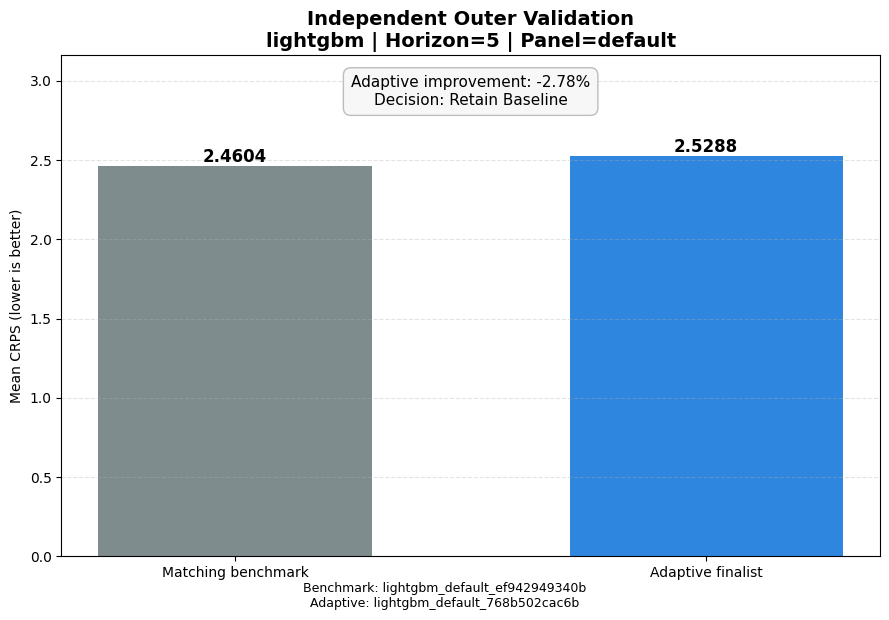

,parameter,matching_benchmark,adaptive_finalist,changed
0,colsample_bytree,LightGBM default,1.000000,True
1,lags_past_covariates,5,21.000000,True
2,learning_rate,LightGBM default,0.057574,True
3,max_depth,LightGBM default,-1.000000,True
4,min_child_samples,LightGBM default,40.000000,True
5,n_estimators,LightGBM default,150.000000,True
6,num_leaves,LightGBM default,15.000000,True
7,reg_alpha,LightGBM default,0.278988,True
8,reg_lambda,LightGBM default,1.460723,True
9,subsample,LightGBM default,0.700000,True


In [27]:
import matplotlib.pyplot as plt
import pandas as pd


assert VALIDATION_RESULT is not None, (
    "Run the outer-validation cell first."
)

assert (
    VALIDATION_RESULT["status"]
    == "success"
), "Outer validation did not complete successfully."


OUTER_VALIDATION_DF = pd.DataFrame([
    {
        "model": "Matching benchmark",
        "candidate_id": (
            VALIDATION_RESULT[
                "baseline"
            ]["candidate_id"]
        ),
        "mean_crps": (
            VALIDATION_RESULT[
                "baseline"
            ]["mean_crps"]
        ),
    },
    {
        "model": "Adaptive finalist",
        "candidate_id": (
            VALIDATION_RESULT[
                "candidate"
            ]["candidate_id"]
        ),
        "mean_crps": (
            VALIDATION_RESULT[
                "candidate"
            ]["mean_crps"]
        ),
    },
])

improvement_pct = float(
    VALIDATION_RESULT[
        "improvement_pct"
    ]
)

decision = VALIDATION_RESULT[
    "decision"
]


fig, ax = plt.subplots(
    figsize=(9, 6)
)

bars = ax.bar(
    OUTER_VALIDATION_DF["model"],
    OUTER_VALIDATION_DF["mean_crps"],
    color=[
        "#7F8C8D",
        "#2E86DE",
    ],
    width=0.58,
)

ax.set_title(
    "Independent Outer Validation\n"
    f"{METHOD} | Horizon={HORIZON} | "
    f"Panel={COVARIATE_PANEL}",
    fontsize=14,
    fontweight="bold",
)

ax.set_ylabel(
    "Mean CRPS (lower is better)"
)

ax.set_ylim(
    0,
    OUTER_VALIDATION_DF[
        "mean_crps"
    ].max() * 1.25,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35,
)

for bar, value in zip(
    bars,
    OUTER_VALIDATION_DF[
        "mean_crps"
    ],
    strict=True,
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

comparison_text = (
    f"Adaptive improvement: "
    f"{improvement_pct:.2f}%\n"
    f"Decision: "
    f"{decision.replace('_', ' ').title()}"
)

ax.text(
    0.5,
    0.96,
    comparison_text,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "#F7F7F7",
        "edgecolor": "#BDBDBD",
    },
)

benchmark_id = (
    VALIDATION_RESULT[
        "baseline"
    ]["candidate_id"]
)

adaptive_id = (
    VALIDATION_RESULT[
        "candidate"
    ]["candidate_id"]
)

fig.text(
    0.5,
    -0.02,
    (
        f"Benchmark: {benchmark_id}\n"
        f"Adaptive: {adaptive_id}"
    ),
    ha="center",
    fontsize=9,
)

fig.tight_layout()

plt.show()

def flatten_parameters(
    parameters: dict,
) -> dict:
    """Flatten predictor-level and LightGBM parameters."""

    flattened = {}

    for name, value in parameters.items():
        if (
            name == "lgbm_kwargs"
            and isinstance(value, dict)
        ):
            flattened.update(value)
        else:
            flattened[name] = value

    return flattened


# Prefer the exact parameters returned by validation.
# Use configuration/state as a fallback.
BASELINE_PARAMETERS = (
    VALIDATION_RESULT[
        "baseline"
    ].get("parameters")
    or get_benchmark_config(
        METHOD,
        COVARIATE_PANEL,
    )
)

ADAPTIVE_PARAMETERS = (
    VALIDATION_RESULT[
        "candidate"
    ].get("parameters")
    or STUDY_RECORD[
        "best_parameters"
    ]
)

baseline_flat = flatten_parameters(
    BASELINE_PARAMETERS
)

adaptive_flat = flatten_parameters(
    ADAPTIVE_PARAMETERS
)

parameter_names = sorted(
    set(baseline_flat)
    | set(adaptive_flat)
)

PARAMETER_COMPARISON = pd.DataFrame([
    {
        "parameter": parameter,
        "matching_benchmark": (
            baseline_flat.get(
                parameter,
                "LightGBM default",
            )
        ),
        "adaptive_finalist": (
            adaptive_flat.get(
                parameter,
                "LightGBM default",
            )
        ),
        "changed": (
            baseline_flat.get(
                parameter,
                "LightGBM default",
            )
            != adaptive_flat.get(
                parameter,
                "LightGBM default",
            )
        ),
    }
    for parameter in parameter_names
])

PARAMETER_COMPARISON = (
    PARAMETER_COMPARISON.sort_values(
        [
            "changed",
            "parameter",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)




display(
    PARAMETER_COMPARISON
    
)